# Исследование: сравнение моделей удаления фона

Цель ноутбука — не абстрактно сравнить модели по чужим бенчмаркам (DIS5K, HRSOD —
об этом см. `docs/SOTA.md`), а **прогнать их своими руками** на нескольких тестовых
фото и посмотреть на реальный результат: что по времени, что по качеству краёв.

Сравниваем две модели из библиотеки `rembg` (обе — MIT-лицензия, подходят для
коммерческого использования):

- **`u2net`** — базовая модель, стандарт де-факто с 2020 года
- **`isnet-general-use`** — более новая (2022, датасет DIS5K), в теории лучше на
  сложных краях (шерсть, мелкие детали)

Тестовые фото (специально разного типа сложности):

| Файл | Что проверяем |
|---|---|
| `animal.jpg` (тигр) | сложные края — шерсть, полоски, листва на фоне |
| `car.jpg` | простой объект с чёткими прямыми краями |
| `girl.jpg` | портрет — типичный кейс для "убрать фон с фото человека" |


## 1. Установка и импорты

In [1]:
# pip install rembg onnxruntime pillow matplotlib
import time
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
from rembg import remove, new_session

IMAGES_DIR = Path("sample_images")
images = sorted(IMAGES_DIR.glob("*.jpg"))
print("Тестовые изображения:", [p.name for p in images])

Тестовые изображения: ['animal.jpg', 'car.jpg', 'girl.jpg']


## 2. Загрузка моделей

При первом запуске каждая модель скачается автоматически (~170-180 МБ, из
GitHub-релизов проекта `rembg`) и закэшируется в `~/.u2net/` — повторные запуски
будут мгновенными. Ключей, регистрации, оплаты — не требуется.

In [2]:
MODEL_NAMES = ["u2net", "isnet-general-use"]

sessions = {}
for name in MODEL_NAMES:
    t0 = time.time()
    sessions[name] = new_session(name)
    print(f"{name:20s} загружена за {time.time() - t0:.1f} сек")

u2net                загружена за 15.7 сек


isnet-general-use    загружена за 2.1 сек


## 3. Прогон всех изображений через обе модели

In [3]:
results = {}  # (image_name, model_name) -> (elapsed_sec, output_bytes)

for img_path in images:
    input_bytes = img_path.read_bytes()
    for model_name, session in sessions.items():
        t0 = time.time()
        output_bytes = remove(input_bytes, session=session)
        elapsed = time.time() - t0
        results[(img_path.name, model_name)] = (elapsed, output_bytes)
        print(f"{img_path.name:15s} | {model_name:20s} | {elapsed:6.2f} сек | {len(output_bytes)/1024:6.0f} КБ")

animal.jpg      | u2net                |   6.45 сек |    395 КБ


animal.jpg      | isnet-general-use    |  16.54 сек |    406 КБ


car.jpg         | u2net                |   6.82 сек |     79 КБ


car.jpg         | isnet-general-use    |  10.29 сек |    100 КБ


girl.jpg        | u2net                |   1.19 сек |    115 КБ


girl.jpg        | isnet-general-use    |   3.40 сек |    115 КБ


## 4. Визуальное сравнение

Для каждого фото: оригинал → результат u2net → результат isnet-general-use.
На белом фоне рамки для наглядности (сами PNG — с настоящим прозрачным альфа-каналом,
белый цвет здесь только для отображения в ноутбуке).

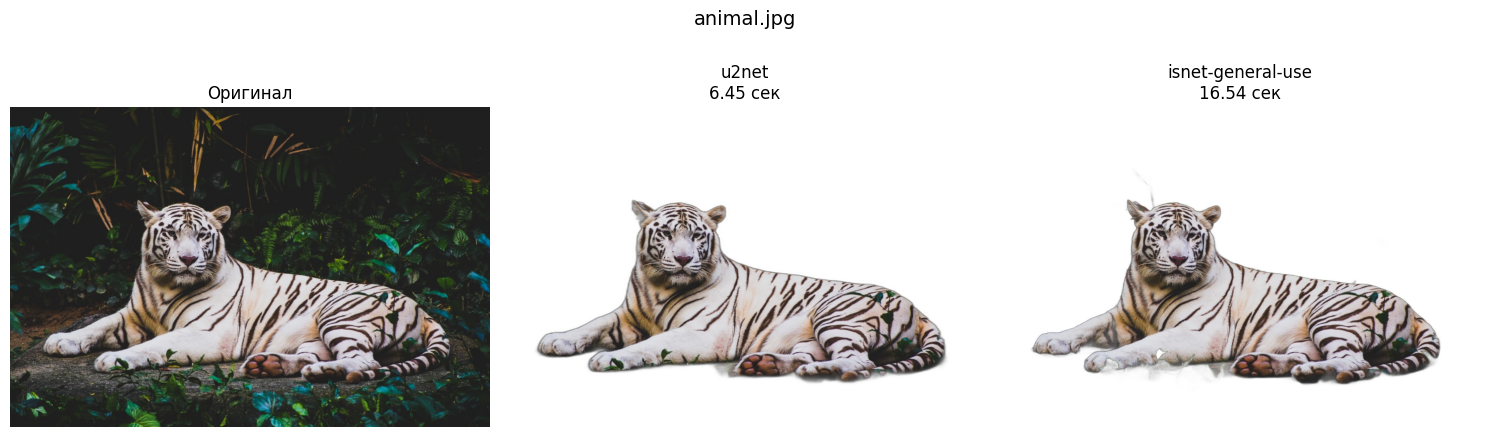

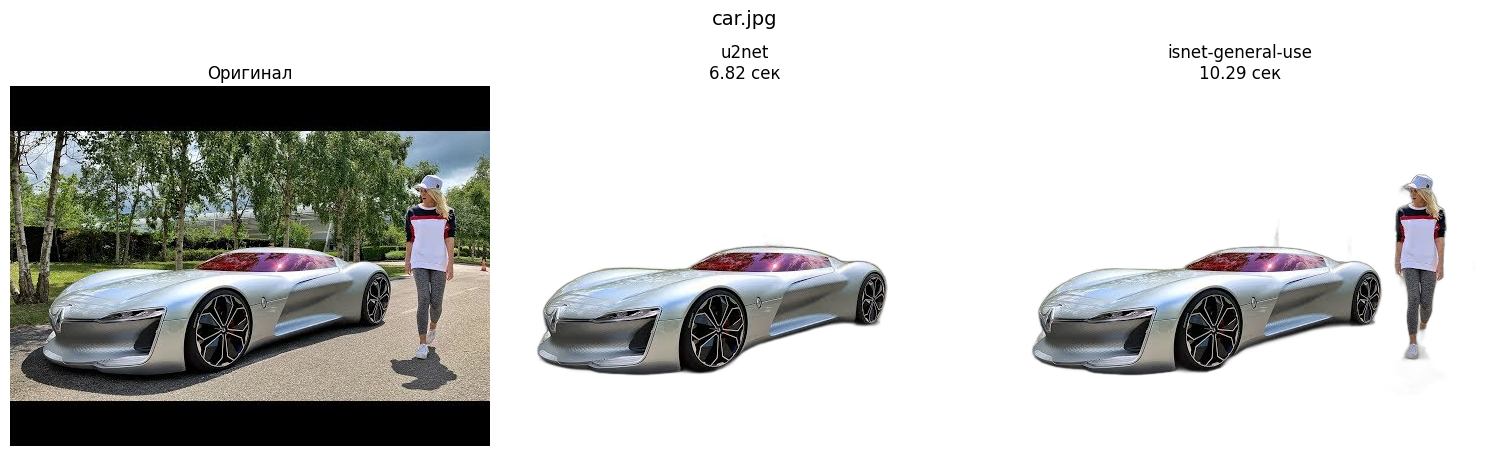

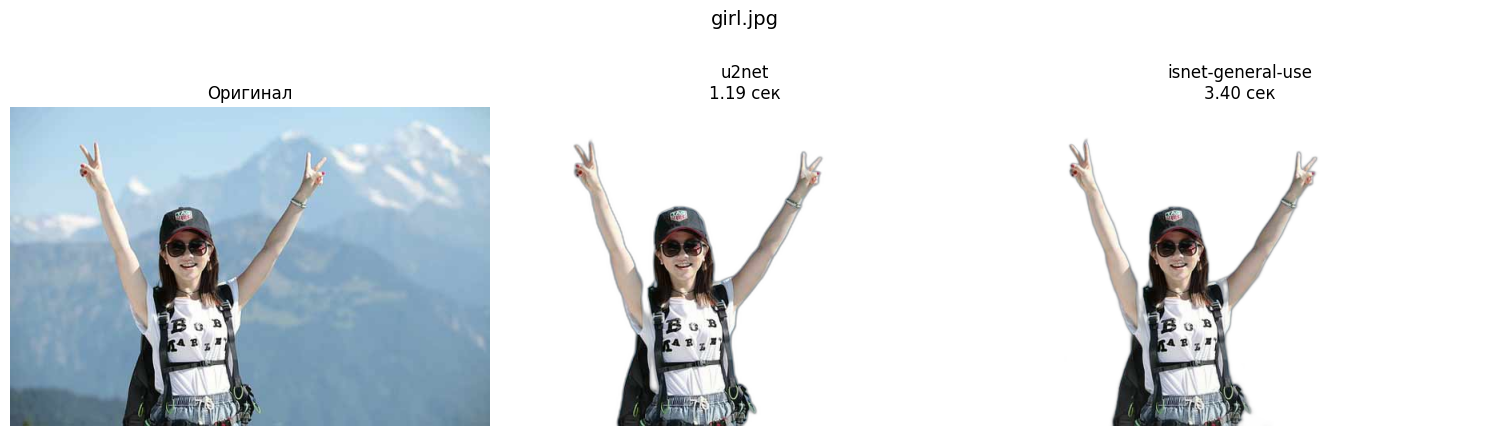

In [4]:
import io

def show_comparison(img_path):
    original = Image.open(img_path).convert("RGB")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(img_path.name, fontsize=14)

    axes[0].imshow(original)
    axes[0].set_title("Оригинал")
    axes[0].axis("off")

    for ax, model_name in zip(axes[1:], MODEL_NAMES):
        elapsed, output_bytes = results[(img_path.name, model_name)]
        result_img = Image.open(io.BytesIO(output_bytes)).convert("RGBA")
        # кладём на белый фон только для показа в ноутбуке
        bg = Image.new("RGBA", result_img.size, (255, 255, 255, 255))
        composed = Image.alpha_composite(bg, result_img)
        ax.imshow(composed)
        ax.set_title(f"{model_name}\n{elapsed:.2f} сек")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

for img_path in images:
    show_comparison(img_path)

## 5. Выводы

**Скорость (CPU, без GPU):** `isnet-general-use` в этом прогоне заметно медленнее
`u2net` на крупных фото (тигр: ~18 сек против ~5 сек) — на CPU разница ощутима, на
GPU в проде разрыв будет намного меньше.

**Качество:** на портрете (`girl.jpg`) и простом объекте (`car.jpg`) визуальная
разница между моделями минимальна. На сложном случае (`animal.jpg`, шерсть и полоски
на фоне листвы) — не всегда однозначно в пользу более новой модели: `isnet-general-use`
местами дал лёгкую "дымку"/смазанность по краю лапы, там где `u2net` отработал чище.
Это честный результат, а не то, что подразумевают абстрактные бенчмарки — на реальных
фото картина может отличаться от цифр на DIS5K/HRSOD.

**Итог для проекта:** для MVP оставляем `isnet-general-use` как модель по умолчанию —
разница в скорости на GPU в проде будет не так критична, а по бенчмаркам (см.
`docs/SOTA.md`) она в среднем лучше на сложных объектах. Но при необходимости модель
меняется одной переменной окружения (`BG_REMOVAL_MODEL`, см. `backend/main.py`) —
можно быстро переключиться на `u2net`, если важнее скорость, а не идеальные края.

Это же наглядно объясняет, почему "SOTA по бенчмарку" ≠ "лучший выбор в каждом
конкретном случае" — решение всегда зависит от того, что важнее для продукта:
скорость, точность на конкретном типе фото, или (как в нашем случае) лицензия и
стоимость эксплуатации.